In [1]:
import pandas as pd

path = "data/dataset.csv"

# Cargamos el dataset
df = pd.read_csv(path)

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 223 entries, 0 to 222
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   SMILES                 223 non-null    object 
 1   Molecular_Weight       223 non-null    float64
 2   Polar_Area             223 non-null    float64
 3   Complexity             223 non-null    int64  
 4   XLogP                  98 non-null     float64
 5   Heavy_Atom_Count       223 non-null    int64  
 6   H-Bond_Donor_Count     223 non-null    int64  
 7   H-Bond_Acceptor_Count  223 non-null    int64  
 8   Charge                 223 non-null    int64  
 9   Covalent_Unit_Count    223 non-null    int64  
 10  es_natural             223 non-null    bool   
dtypes: bool(1), float64(3), int64(6), object(1)
memory usage: 17.8+ KB


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Creamos una copia para graficar sin nulos en XLogP
df_plot = df.dropna(subset=['XLogP']).copy()

# Seteamos un estilo profesional
sns.set_theme(style="whitegrid")

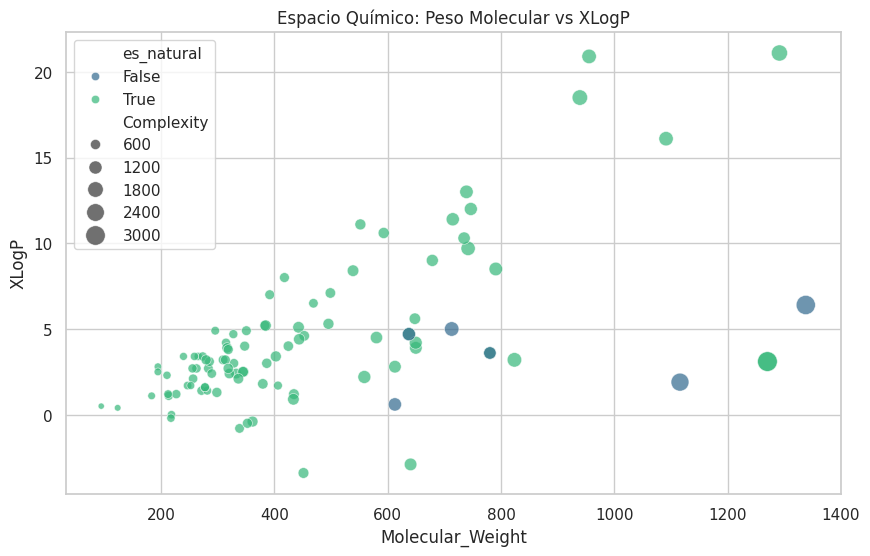

In [4]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_plot, 
    x='Molecular_Weight', 
    y='XLogP', 
    hue='es_natural', 
    size='Complexity', 
    sizes=(20, 200),
    palette='viridis',
    alpha=0.7
)
plt.title('Espacio Químico: Peso Molecular vs XLogP')
plt.show()

/tmp/ipykernel_51705/140915500.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='es_natural', y='H-Bond_Donor_Count', palette='Set2')


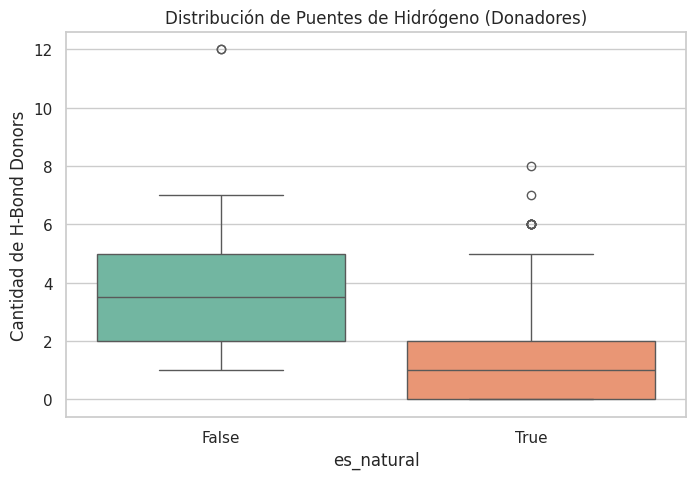

In [5]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='es_natural', y='H-Bond_Donor_Count', palette='Set2')
plt.title('Distribución de Puentes de Hidrógeno (Donadores)')
plt.ylabel('Cantidad de H-Bond Donors')
plt.show()

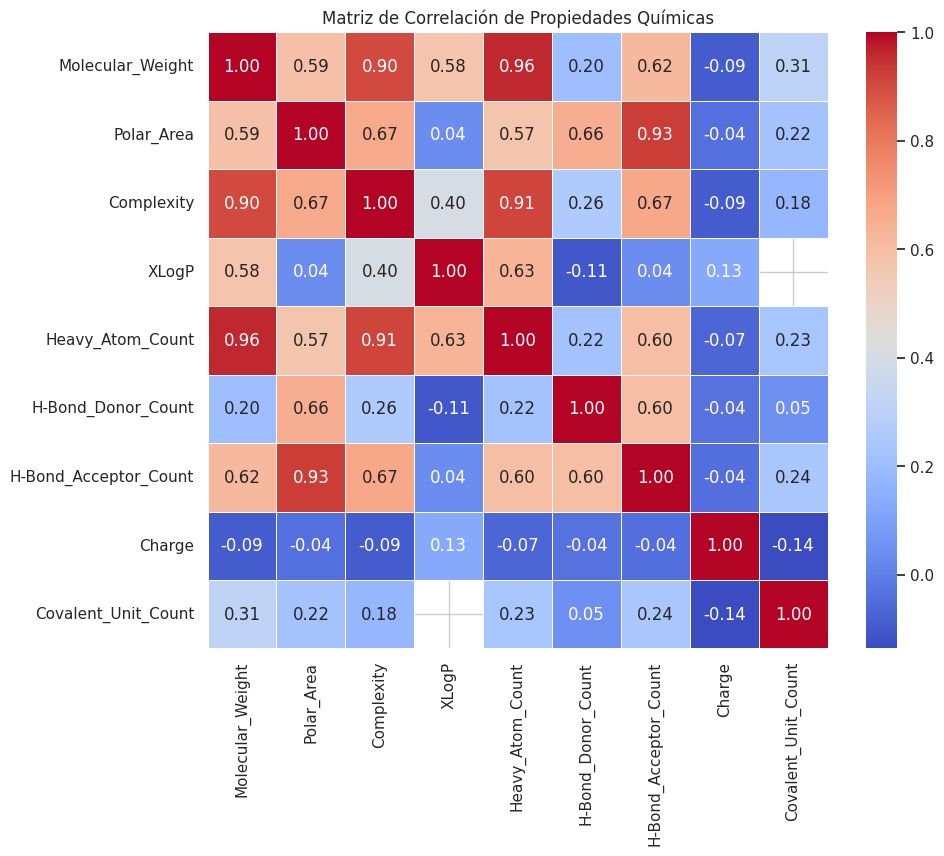

In [6]:
plt.figure(figsize=(10, 8))
# Seleccionamos solo columnas numéricas para el heatmap
corr = df.select_dtypes(include=['number']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de Propiedades Químicas')
plt.show()